In [57]:
import os
import pandas as pd
import numpy as np
import random
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Flatten, Conv2D
import matplotlib.pyplot as plt


In [58]:


image_dir = "Project/Image/ALL_P"  # All Image directory 
image_size = (32,32)
batch_size = 32
num_classes = 2


image_files = [f for f in os.listdir(image_dir) if f.endswith((".jpg", ".jpeg", ".png"))]
random.shuffle(image_files) # Shuffle the image files for random distribution
labels = [f.split("_")[0] for f in image_files]  # extract label from filename

df = pd.DataFrame({
    "filename": image_files,
    "class": labels
})

# Splitting dataframe for training, validation, and testing(1 time i split for val and test only)
train_df, temp_df = train_test_split(df, test_size=0.2, stratify=df["class"], random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.5, stratify=temp_df["class"], random_state=42)


datagen = ImageDataGenerator(rescale=1./255)

train_gen = datagen.flow_from_dataframe(
    train_df,
    directory=image_dir,
    x_col="filename",
    y_col="class",
    target_size=image_size,
    batch_size=batch_size,
    class_mode="sparse"
)

val_gen = datagen.flow_from_dataframe(
    val_df,
    directory=image_dir,
    x_col="filename",
    y_col="class",
    target_size=image_size,
    batch_size=batch_size,
    class_mode="sparse"
)

test_gen = datagen.flow_from_dataframe(
    test_df,
    directory=image_dir,
    x_col="filename",
    y_col="class",
    target_size=image_size,
    batch_size=batch_size,
    class_mode="sparse",
    shuffle=False
)

# Convert class labels to integers (Keep them as single integers, not one-hot encoded vectors)
inputs = Input(shape=(32, 32, 3))
x = Conv2D(8, (3, 3), activation='relu')(inputs)
x = Conv2D(8, (3, 3), activation='relu')(x)
x = Flatten()(x)
x = Dense(64, activation='relu')(x)
x = Dense(128, activation='relu')(x)
x = Dense(64, activation='relu')(x)
outputs = Dense(num_classes, activation='softmax')(x)

model = Model(inputs, outputs)
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.summary()

history = model.fit(train_gen, epochs=10, validation_data=val_gen)

loss, accuracy = model.evaluate(test_gen)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")


Found 800 validated image filenames belonging to 2 classes.
Found 100 validated image filenames belonging to 2 classes.
Found 100 validated image filenames belonging to 2 classes.


Model: "functional_17"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_17 (InputLayer)     │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_34 (Conv2D)              │ (None, 30, 30, 8)      │           224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_35 (Conv2D)              │ (None, 28, 28, 8)      │           584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_17 (Flatten)            │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_68 (Dense)                │ (None, 64)             │       401,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_69 (Dense)                │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_70 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_71 (Dense)                │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 418,986 (1.60 MB)

 Trainable params: 418,986 (1.60 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10


/home/apd/code/CSE_Lab/CSE_4_1/myenv/lib/python3.10/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


25/25 ━━━━━━━━━━━━━━━━━━━━ 7s 127ms/step - accuracy: 0.5575 - loss: 0.6800 - val_accuracy: 0.5600 - val_loss: 0.6821
Epoch 2/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 48ms/step - accuracy: 0.6250 - loss: 0.6131 - val_accuracy: 0.7200 - val_loss: 0.5712
Epoch 3/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - accuracy: 0.7887 - loss: 0.4685 - val_accuracy: 0.7800 - val_loss: 0.4517
Epoch 4/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - accuracy: 0.8662 - loss: 0.3094 - val_accuracy: 0.8300 - val_loss: 0.3729
Epoch 5/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - accuracy: 0.9237 - loss: 0.1836 - val_accuracy: 0.9200 - val_loss: 0.2264
Epoch 6/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - accuracy: 0.9438 - loss: 0.1397 - val_accuracy: 0.9600 - val_loss: 0.1491
Epoch 7/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - accuracy: 0.9762 - loss: 0.0845 - val_accuracy: 0.9500 - val_loss: 0.1889
Epoch 8/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - accuracy: 0.9613 - loss: 0.1106 - val_accuracy: 0.9700 - val_loss: 0

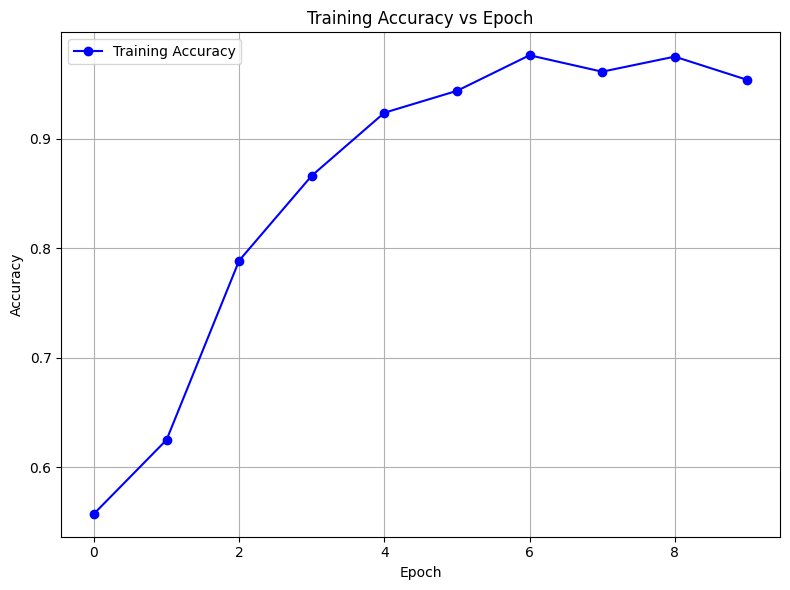

In [59]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.plot(history.history['accuracy'], label='Training Accuracy', marker='o', color='blue')
plt.title('Training Accuracy vs Epoch')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


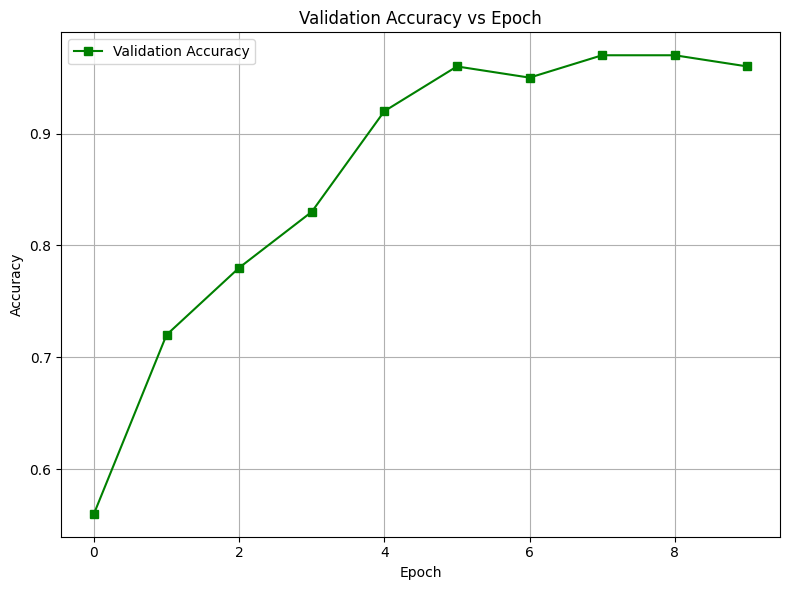

In [60]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', marker='s', color='green')
plt.title('Validation Accuracy vs Epoch')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 169ms/step


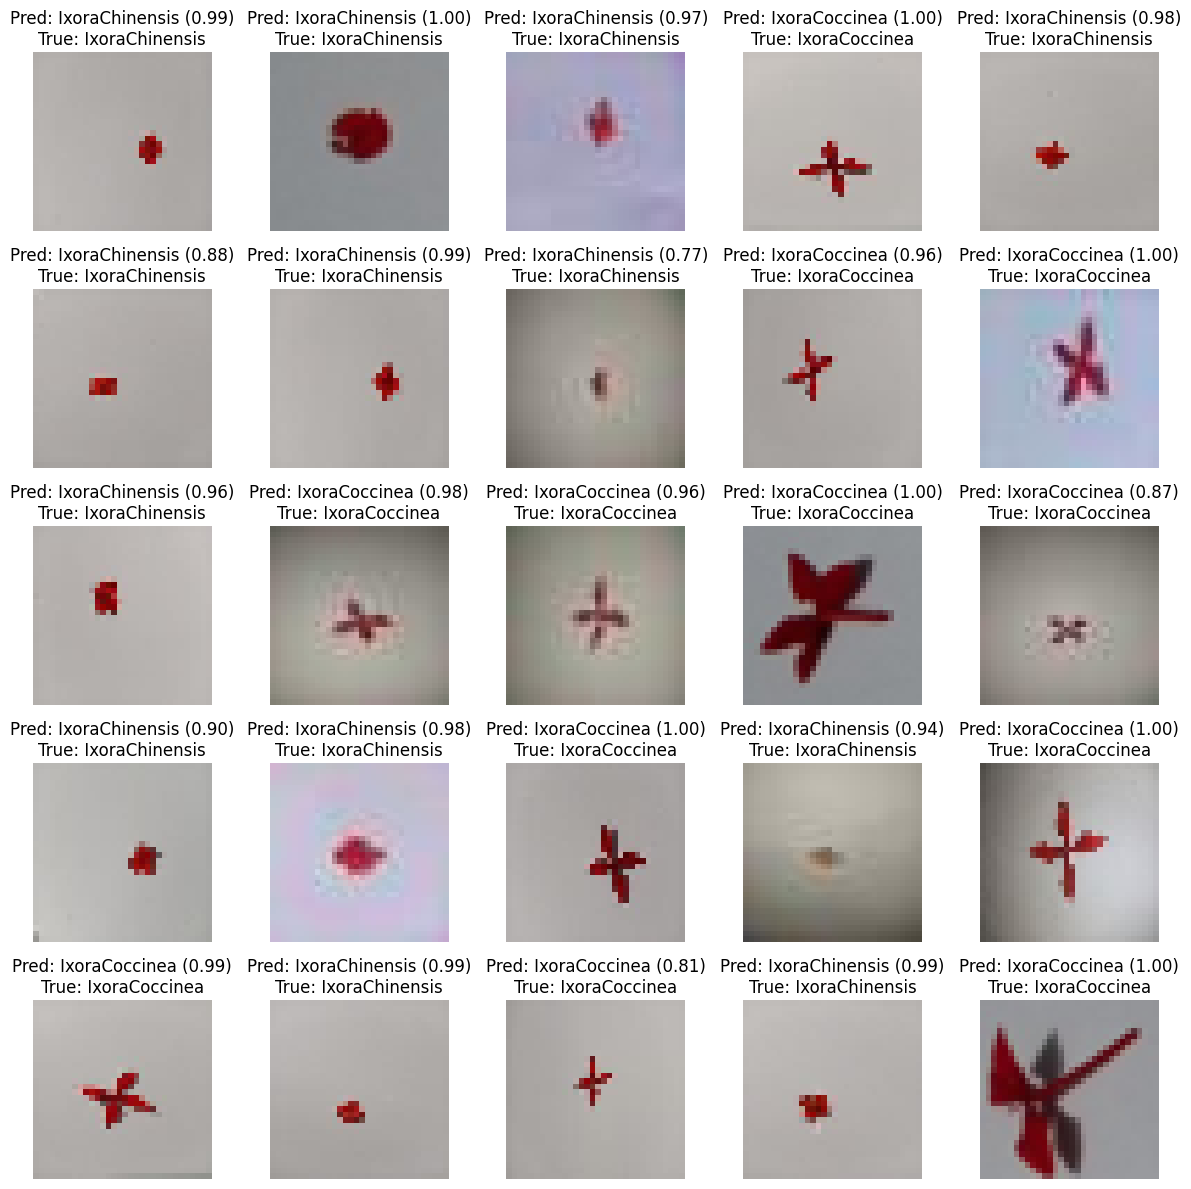

In [61]:
import matplotlib.pyplot as plt
import numpy as np


test_images, test_labels = next(test_generator)  # one batch of test data
pred_probs = model.predict(test_images)          # predict probabilities
pred_labels = np.argmax(pred_probs, axis=1)      # get predicted class indices


class_names = list(test_generator.class_indices.keys())

plt.figure(figsize=(12, 12))
for i in range(25):
    plt.subplot(5, 5, i + 1)
    if(i >= len(test_images)):
        break
    img = test_images[i]
    true_label = int(test_labels[i])
    pred_label = pred_labels[i]
    confidence = pred_probs[i][pred_label]  # confidence of predicted class
    
    plt.imshow(img)
    plt.title(f"Pred: {class_names[pred_label]} ({confidence:.2f})\nTrue: {class_names[true_label]}")
    plt.axis("off")

plt.tight_layout()
plt.show()
